# Sentinel-1 / Own LiDAR Patch Collocation -- Michel's Stricter Matcher

**Purpose:** re-collocate this project's own LiDAR patches (`lidar_patches_tuk`, 1708 patches) against the already-calibrated Sentinel-1 products (`t0.tif`-`t7.tif`, EPSG:6931), using Michel Tsamados's stricter `extract_lidar_matched_s1_patches` matching logic in place of this project's original, looser `collocate()`.

**Why this is quick (no recalibration needed):** your own LiDAR patches were generated in the same CRS (EPSG:6931) as the existing calibrated Sentinel-1 products, so there is no CRS mismatch to resolve here -- unlike the separate `05_sentinel1_tessa_collocation_utm8n.ipynb` notebook, which needs a full ~4-5 hour recalibration pass because Tessa's patches are in a different CRS (UTM Zone 8N). This notebook only re-runs the matching step against data that already exists on disk.

**How this differs from the original `collocate()` (in `03_sentinel1_preprocessing.ipynb`):**

| | Original `collocate()` | Michel's `extract_lidar_matched_s1_patches` |
|---|---|---|
| Window size | Whatever the reprojected bounds produce | Fixed target (26 px for 256px patches @ 10m); any mismatch is rejected |
| Rejection scope | Skips only the failing product's timestep | Rejects the **entire patch** if any single product fails |
| NaN tolerance | Only checks "is everything NaN" | Explicit `max_nan_frac` threshold (default 2%) |

Expect **fewer than 1708 written patches** as a result -- some patches near the true swath edge that the looser function partially kept will now be dropped entirely. Fewer patches, but each one guaranteed clean (exact size, <=2% NaN) across all 8 timesteps.

## 1. Imports

In [1]:
import os
import json
import glob as glob_module

import numpy as np
import rasterio
from rasterio.warp import transform_bounds
from rasterio.windows import Window, from_bounds

## 2. Configuration

Points at your own already-existing LiDAR patches and already-calibrated Sentinel-1 products -- nothing new to download or compute. `out_s1_dir` uses a **new** name (`s1_patches_tuk_michel`) so this run doesn't overwrite the existing (currently stale) `s1_patches_tuk/` or the separate `s1_patches_tuk_tessa/`.

In [2]:
REPO_DIR = '/cs/student/project_msc/2025/aibh/jiayiche'
REGION = 'tuk'

patch_size = 256
s1_patch_size = int(round(patch_size / 10))  # 26 px @ 10m IW resolution

lidar_patches_dir = f'{REPO_DIR}/input_data/lidar_patches_{REGION}'          # your own patches, EPSG:6931
DIY_CORRECTED_DIR = f'{REPO_DIR}/raw_data/{REGION}_sentinel1_diy_corrected'   # your existing t0..t7, EPSG:6931
out_s1_dir = f'{REPO_DIR}/input_data/s1_patches_{REGION}_michel'
os.makedirs(out_s1_dir, exist_ok=True)

print('s1_patch_size:', s1_patch_size)
print('lidar_patches_dir:', lidar_patches_dir)
print('out_s1_dir:', out_s1_dir)

s1_patch_size: 26
lidar_patches_dir: /cs/student/project_msc/2025/aibh/jiayiche/input_data/lidar_patches_tuk
out_s1_dir: /cs/student/project_msc/2025/aibh/jiayiche/input_data/s1_patches_tuk_michel


## 3. Locate the already-calibrated Sentinel-1 products

Sorted numerically by timestep index (`t0`, `t1`, ..., `t7`) rather than alphabetically, so a plain string sort doesn't accidentally order `t10` before `t2` (not an issue at 8 products, but a safe habit).

In [3]:
CORRECTED_S1_PATHS = sorted(
    glob_module.glob(os.path.join(DIY_CORRECTED_DIR, 't*.tif')),
    key=lambda p: int(os.path.basename(p)[1:-4])
)
print(f'Using {len(CORRECTED_S1_PATHS)} already-calibrated products:')
for p in CORRECTED_S1_PATHS:
    print(' ', p)

Using 8 already-calibrated products:
  /cs/student/project_msc/2025/aibh/jiayiche/raw_data/tuk_sentinel1_diy_corrected/t0.tif
  /cs/student/project_msc/2025/aibh/jiayiche/raw_data/tuk_sentinel1_diy_corrected/t1.tif
  /cs/student/project_msc/2025/aibh/jiayiche/raw_data/tuk_sentinel1_diy_corrected/t2.tif
  /cs/student/project_msc/2025/aibh/jiayiche/raw_data/tuk_sentinel1_diy_corrected/t3.tif
  /cs/student/project_msc/2025/aibh/jiayiche/raw_data/tuk_sentinel1_diy_corrected/t4.tif
  /cs/student/project_msc/2025/aibh/jiayiche/raw_data/tuk_sentinel1_diy_corrected/t5.tif
  /cs/student/project_msc/2025/aibh/jiayiche/raw_data/tuk_sentinel1_diy_corrected/t6.tif
  /cs/student/project_msc/2025/aibh/jiayiche/raw_data/tuk_sentinel1_diy_corrected/t7.tif


**Check before continuing:** confirm this printed **8** -- matching the verified, coverage-filtered product set. If it shows a different number, stop and investigate before running the match.

## 4. Matching functions (Michel's code, unchanged)

- `build_s1_products_from_corrected`: opens each already-calibrated GeoTIFF **without** reading its full contents into memory -- just keeps the file handle plus its CRS/transform/size, so the matching loop below can read small windows on demand.
- `close_products`: releases the open file handles once matching is done.
- `extract_lidar_matched_s1_patches`: the actual collocation loop -- for every existing LiDAR patch, computes the matching window in each product, enforces the exact-size and low-NaN checks described above, and writes out a clean patch only if every product passes.

In [4]:
def build_s1_products_from_corrected(geotiff_paths, attrs_jsons=None):
    products = []
    for i, path in enumerate(geotiff_paths):
        src = rasterio.open(path)
        attrs = None
        if attrs_jsons and i < len(attrs_jsons) and attrs_jsons[i] and os.path.exists(attrs_jsons[i]):
            with open(attrs_jsons[i]) as jf:
                attrs = json.load(jf)
        products.append({"src": src, "crs": src.crs, "transform": src.transform,
                          "height": src.height, "width": src.width, "attrs": attrs})
    if not products:
        raise ValueError("No Sentinel-1 products loaded -- check geotiff_paths.")
    return products


def close_products(products):
    for p in products:
        p["src"].close()


def extract_lidar_matched_s1_patches(lidar_patches_dir, sentinel1_products, s1_patch_size,
                                      out_s1_dir, pattern="lidar_patch_*.tif", max_nan_frac=0.02):
    lidar_paths = sorted(glob_module.glob(os.path.join(lidar_patches_dir, pattern)))
    print(f"Found {len(lidar_paths)} existing LiDAR patches to match against "
          f"{len(sentinel1_products)} Sentinel-1 product(s).")

    n_written, n_skipped, n_skipped_nan = 0, 0, 0

    for idx, lp in enumerate(lidar_paths):
        if idx % 100 == 0:
            print(f"  ...processed {idx}/{len(lidar_paths)} "
                  f"(written: {n_written}, skipped: {n_skipped}, skipped-NaN: {n_skipped_nan})")

        patch_id = os.path.splitext(os.path.basename(lp))[0].split("_")[-1]

        with rasterio.open(lp) as lsrc:
            lidar_bounds = lsrc.bounds
            lidar_crs = lsrc.crs

        s1_patches, s1_transforms = [], []
        ok = True
        has_too_much_nan = False
        for prod in sentinel1_products:
            try:
                s1_bounds = transform_bounds(lidar_crs, prod["crs"], *lidar_bounds, densify_pts=21)
                window = from_bounds(*s1_bounds, transform=prod["transform"]).round_offsets().round_lengths()
                r0, c0 = int(window.row_off), int(window.col_off)
                hh, ww = int(window.height), int(window.width)

                if (hh, ww) != (s1_patch_size, s1_patch_size):
                    ok = False; break
                if r0 < 0 or c0 < 0:
                    ok = False; break
                if r0 + s1_patch_size > prod["height"] or c0 + s1_patch_size > prod["width"]:
                    ok = False; break

                read_window = Window(c0, r0, s1_patch_size, s1_patch_size)
                patch = prod["src"].read(window=read_window)
                if patch.shape[1:] != (s1_patch_size, s1_patch_size):
                    ok = False; break

                nan_frac = float(np.mean(np.isnan(patch)))
                if nan_frac > max_nan_frac:
                    has_too_much_nan = True
                    break

                s1_patches.append(patch)
                s1_transforms.append(rasterio.windows.transform(read_window, prod["transform"]))
            except Exception:
                ok = False
                break

        if has_too_much_nan:
            n_skipped_nan += 1
            continue

        if not ok or len(s1_patches) != len(sentinel1_products):
            n_skipped += 1
            continue

        patch_dir = os.path.join(out_s1_dir, f"s1_patch_{patch_id}")
        os.makedirs(patch_dir, exist_ok=True)

        attrs_list = []
        for ti, (prod, patch, tr) in enumerate(zip(sentinel1_products, s1_patches, s1_transforms)):
            meta = {
                "driver": "GTiff", "count": patch.shape[0],
                "height": s1_patch_size, "width": s1_patch_size,
                "dtype": "float32", "crs": prod["crs"], "transform": tr,
            }
            with rasterio.open(os.path.join(patch_dir, f"t{ti}.tif"), "w", **meta) as dst:
                dst.write(patch.astype(np.float32))
            attrs_list.append(prod.get("attrs"))

        with open(os.path.join(patch_dir, "attrs.json"), "w") as jf:
            json.dump(attrs_list, jf, indent=2)

        n_written += 1

    print(f"Done. Matched: {n_written}, skipped (out of bounds/wrong size): {n_skipped}, "
          f"skipped (too much NaN, >{max_nan_frac:.0%}): {n_skipped_nan}")
    return n_written, n_skipped

## 5. Run the match (fast -- reads small windows from already-calibrated files, no recalibration; expect well under an hour for 1708 patches)

In [5]:
products_a = build_s1_products_from_corrected(CORRECTED_S1_PATHS)
extract_lidar_matched_s1_patches(lidar_patches_dir, products_a, s1_patch_size, out_s1_dir)
close_products(products_a)

Found 1708 existing LiDAR patches to match against 8 Sentinel-1 product(s).
  ...processed 0/1708 (written: 0, skipped: 0, skipped-NaN: 0)
  ...processed 100/1708 (written: 100, skipped: 0, skipped-NaN: 0)
  ...processed 200/1708 (written: 200, skipped: 0, skipped-NaN: 0)
  ...processed 300/1708 (written: 300, skipped: 0, skipped-NaN: 0)
  ...processed 400/1708 (written: 400, skipped: 0, skipped-NaN: 0)
  ...processed 500/1708 (written: 500, skipped: 0, skipped-NaN: 0)
  ...processed 600/1708 (written: 600, skipped: 0, skipped-NaN: 0)
  ...processed 700/1708 (written: 700, skipped: 0, skipped-NaN: 0)
  ...processed 800/1708 (written: 800, skipped: 0, skipped-NaN: 0)
  ...processed 900/1708 (written: 900, skipped: 0, skipped-NaN: 0)
  ...processed 1000/1708 (written: 1000, skipped: 0, skipped-NaN: 0)
  ...processed 1100/1708 (written: 1100, skipped: 0, skipped-NaN: 0)
  ...processed 1200/1708 (written: 1200, skipped: 0, skipped-NaN: 0)
  ...processed 1300/1708 (written: 1300, skipped: 0

## 6. Verify the output

Same checks used for `s1_patches_tuk_tessa` earlier: confirm the window size came out at the expected fixed 26x26 (no CRS mismatch expected here, since patches and products share EPSG:6931), and look at the distribution of how many timesteps each written patch actually has -- expect most patches at or near 8, not a cliff at 0.

In [6]:
sample_patches = sorted(glob_module.glob(os.path.join(out_s1_dir, 's1_patch_*')))
print(f'Total patches written: {len(sample_patches)} (out of 1708 own LiDAR patches)')

if sample_patches:
    with rasterio.open(os.path.join(sample_patches[0], 't0.tif')) as src:
        print('Sample patch shape:', src.shape, '(expect 26x26)')

from collections import Counter
counts = Counter(len(glob_module.glob(os.path.join(p, 't*.tif'))) for p in sample_patches)
print('Distribution of timesteps per patch:', dict(sorted(counts.items())))

Total patches written: 1708 (out of 1708 own LiDAR patches)
Sample patch shape: (26, 26) (expect 26x26)
Distribution of timesteps per patch: {8: 1708}


## 7. Spot-check one patch's actual data quality

Same per-band `finite_frac`/`nonzero_frac` check used throughout this project's QA process -- confirms the written patch actually contains real, valid backscatter data, not just that a file exists.

In [7]:
if sample_patches:
    patch_dir = sample_patches[0]
    print('Checking:', patch_dir)
    for f in sorted(glob_module.glob(os.path.join(patch_dir, 't*.tif'))):
        with rasterio.open(f) as src:
            arr = src.read()
        print(os.path.basename(f), arr.shape,
              'finite_frac:', round(float(np.isfinite(arr).mean()), 4),
              'nonzero_frac:', round(float((arr != 0).mean()), 4))

Checking: /cs/student/project_msc/2025/aibh/jiayiche/input_data/s1_patches_tuk_michel/s1_patch_00000
t0.tif (2, 26, 26) finite_frac: 1.0 nonzero_frac: 1.0
t1.tif (2, 26, 26) finite_frac: 1.0 nonzero_frac: 1.0
t2.tif (2, 26, 26) finite_frac: 1.0 nonzero_frac: 1.0
t3.tif (2, 26, 26) finite_frac: 1.0 nonzero_frac: 1.0
t4.tif (2, 26, 26) finite_frac: 1.0 nonzero_frac: 1.0
t5.tif (2, 26, 26) finite_frac: 1.0 nonzero_frac: 1.0
t6.tif (2, 26, 26) finite_frac: 1.0 nonzero_frac: 1.0
t7.tif (2, 26, 26) finite_frac: 1.0 nonzero_frac: 1.0


## 8. (Optional) Visual verification

Michel's side-by-side comparison plot -- LiDAR elevation anomaly, valid mask, and Sentinel-1 VV/VH per timestep (converted to dB) for a few random matched patches. Re-run the last line for a fresh random sample each time.

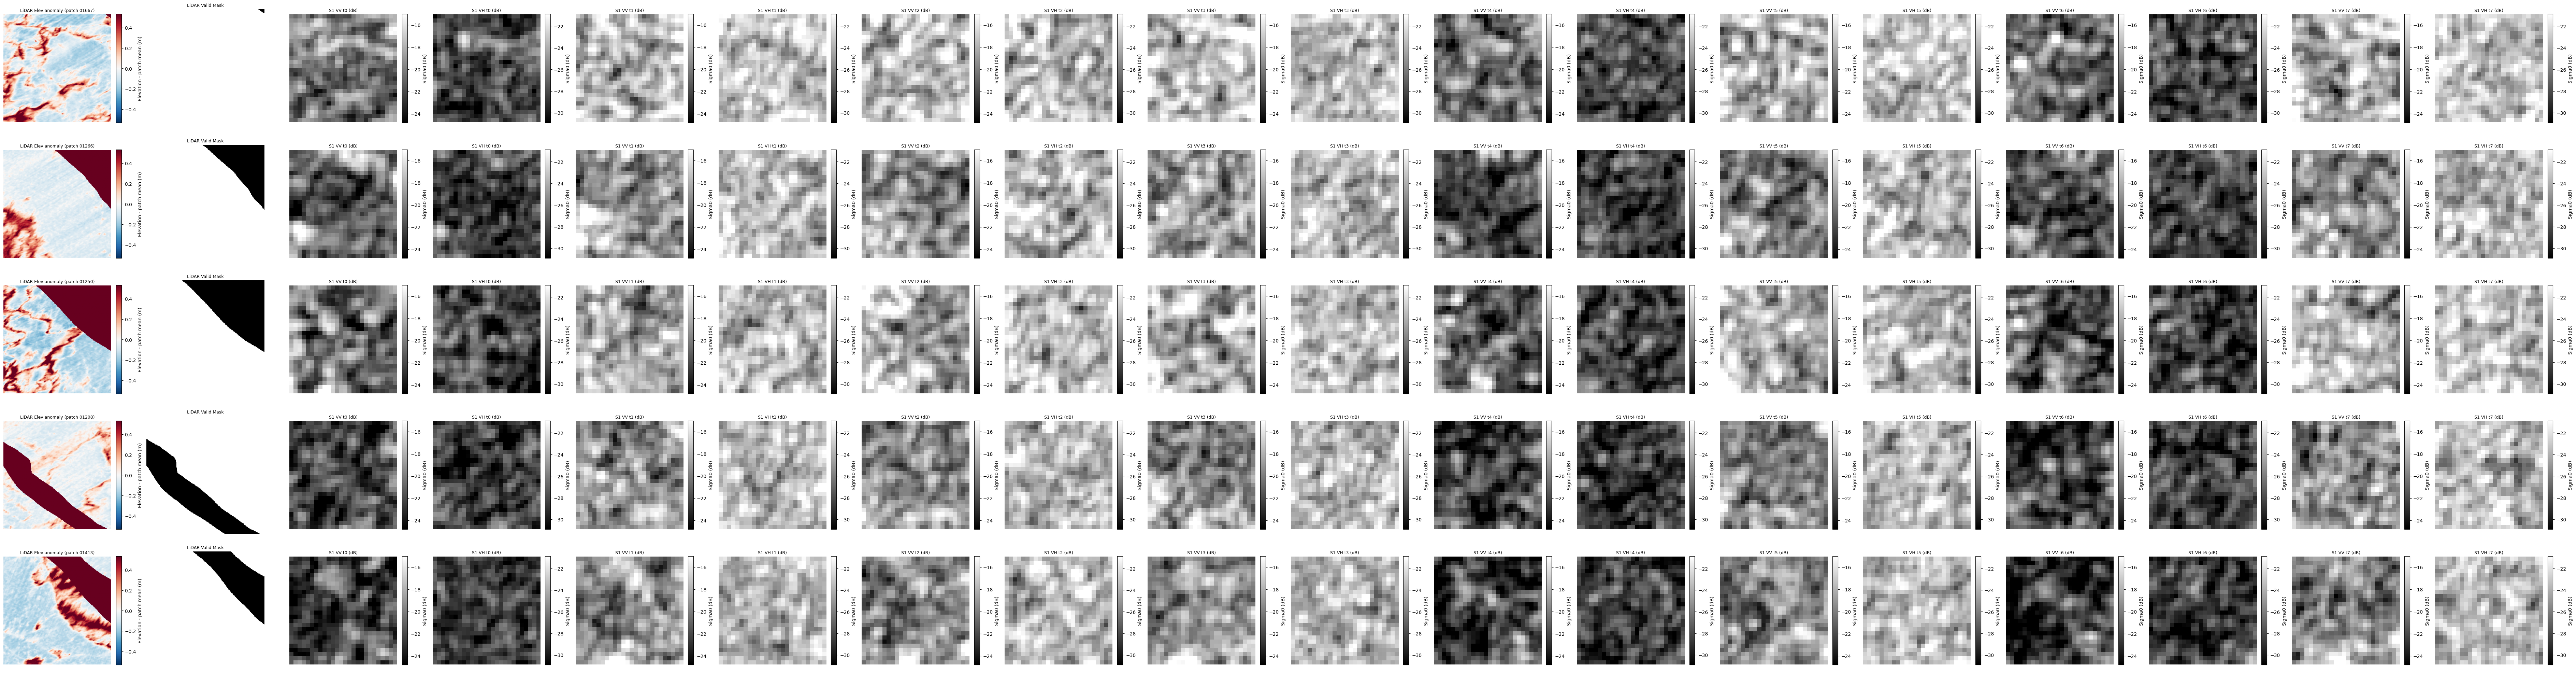

In [8]:
import random
import matplotlib.pyplot as plt

def show_multiple_matched_patches(lidar_patches_dir, out_s1_dir, n_samples=5, seed=None, use_db=True,
                                   pol_labels=("VV", "VH")):
    sample_dirs = sorted(glob_module.glob(os.path.join(out_s1_dir, "s1_patch_*")))
    if not sample_dirs:
        print(f"No matched patches found in {out_s1_dir}")
        return

    rng = random.Random(seed)
    n_samples = min(n_samples, len(sample_dirs))
    picks = rng.sample(sample_dirs, n_samples)
    pids = [os.path.basename(p).split("_")[-1] for p in picks]

    lidar_elevs, lidar_masks = [], []
    s1_stacks = []
    n_bands = None

    for pid in pids:
        lid_path = os.path.join(lidar_patches_dir, f"lidar_patch_{pid}.tif")
        with rasterio.open(lid_path) as src:
            lidar_elevs.append(src.read(1))
            lidar_masks.append(src.read(2))

        s1_dir = os.path.join(out_s1_dir, f"s1_patch_{pid}")
        timestep_stack = []
        for tpath in sorted(glob_module.glob(os.path.join(s1_dir, "t*.tif"))):
            with rasterio.open(tpath) as src:
                arr = src.read()
            if n_bands is None:
                n_bands = arr.shape[0]
            if use_db:
                with np.errstate(divide="ignore", invalid="ignore"):
                    arr = 10 * np.log10(np.where(arr > 0, arr, np.nan))
            timestep_stack.append(arr)
        s1_stacks.append(timestep_stack)

    lidar_anoms = []
    for e, m in zip(lidar_elevs, lidar_masks):
        valid = m.astype(bool)
        patch_mean = e[valid].mean() if valid.any() else e.mean()
        lidar_anoms.append(e - patch_mean)

    valid_anom_vals = np.concatenate([
        a[m.astype(bool)] for a, m in zip(lidar_anoms, lidar_masks) if m.any()
    ]) if any(m.any() for m in lidar_masks) else np.concatenate(lidar_anoms).ravel()
    lo, hi = np.nanpercentile(valid_anom_vals, [2, 98])
    elev_abs_max = max(abs(lo), abs(hi))
    elev_vmin, elev_vmax = -elev_abs_max, elev_abs_max

    band_vmin, band_vmax = [], []
    for b in range(n_bands):
        vals = np.concatenate([ts[b].ravel() for stack in s1_stacks for ts in stack])
        vmin, vmax = np.nanpercentile(vals, [2, 98])
        band_vmin.append(vmin)
        band_vmax.append(vmax)

    labels = list(pol_labels[:n_bands]) if n_bands <= len(pol_labels) else [f"band{b+1}" for b in range(n_bands)]

    n_timesteps = len(s1_stacks[0])
    n_cols = 2 + n_timesteps * n_bands

    fig, axes = plt.subplots(n_samples, n_cols, figsize=(4.2 * n_cols, 4 * n_samples))
    if n_samples == 1:
        axes = axes[None, :]

    for row, pid in enumerate(pids):
        im_elev = axes[row, 0].imshow(lidar_anoms[row], cmap="RdBu_r", vmin=elev_vmin, vmax=elev_vmax)
        axes[row, 0].set_title(f"LiDAR Elev anomaly (patch {pid})", fontsize=9)
        axes[row, 0].axis("off")
        fig.colorbar(im_elev, ax=axes[row, 0], fraction=0.046, pad=0.04, label="Elevation - patch mean (m)")

        axes[row, 1].imshow(lidar_masks[row], cmap="gray", vmin=0, vmax=1)
        axes[row, 1].set_title("LiDAR Valid Mask", fontsize=9)
        axes[row, 1].axis("off")

        col = 2
        for ti, arr in enumerate(s1_stacks[row]):
            for b in range(n_bands):
                im_b = axes[row, col].imshow(arr[b], cmap="gray", vmin=band_vmin[b], vmax=band_vmax[b])
                axes[row, col].set_title(f"S1 {labels[b]} t{ti}" + (" (dB)" if use_db else ""), fontsize=9)
                axes[row, col].axis("off")
                fig.colorbar(im_b, ax=axes[row, col], fraction=0.046, pad=0.04,
                             label="Sigma0 (dB)" if use_db else "Sigma0 (linear)")
                col += 1

    plt.tight_layout()
    plt.show()

show_multiple_matched_patches(lidar_patches_dir, out_s1_dir, n_samples=5)

## 9. (Optional) Quantitative collocation check

Correlates LiDAR roughness (elevation std within a patch) against Sentinel-1 backscatter mean/std across patches. A real, positive correlation is evidence the collocation is genuinely spatially aligned -- rougher terrain physically scatters radar more diffusely. A weak or absent correlation would suggest something is misaligned.

Computed stats for 1708 patches
[VV] Correlation: LiDAR roughness vs mean (dB): 0.618
[VV] Correlation: LiDAR roughness vs std (dB):  0.558
[VH] Correlation: LiDAR roughness vs mean (dB): 0.689
[VH] Correlation: LiDAR roughness vs std (dB):  0.627


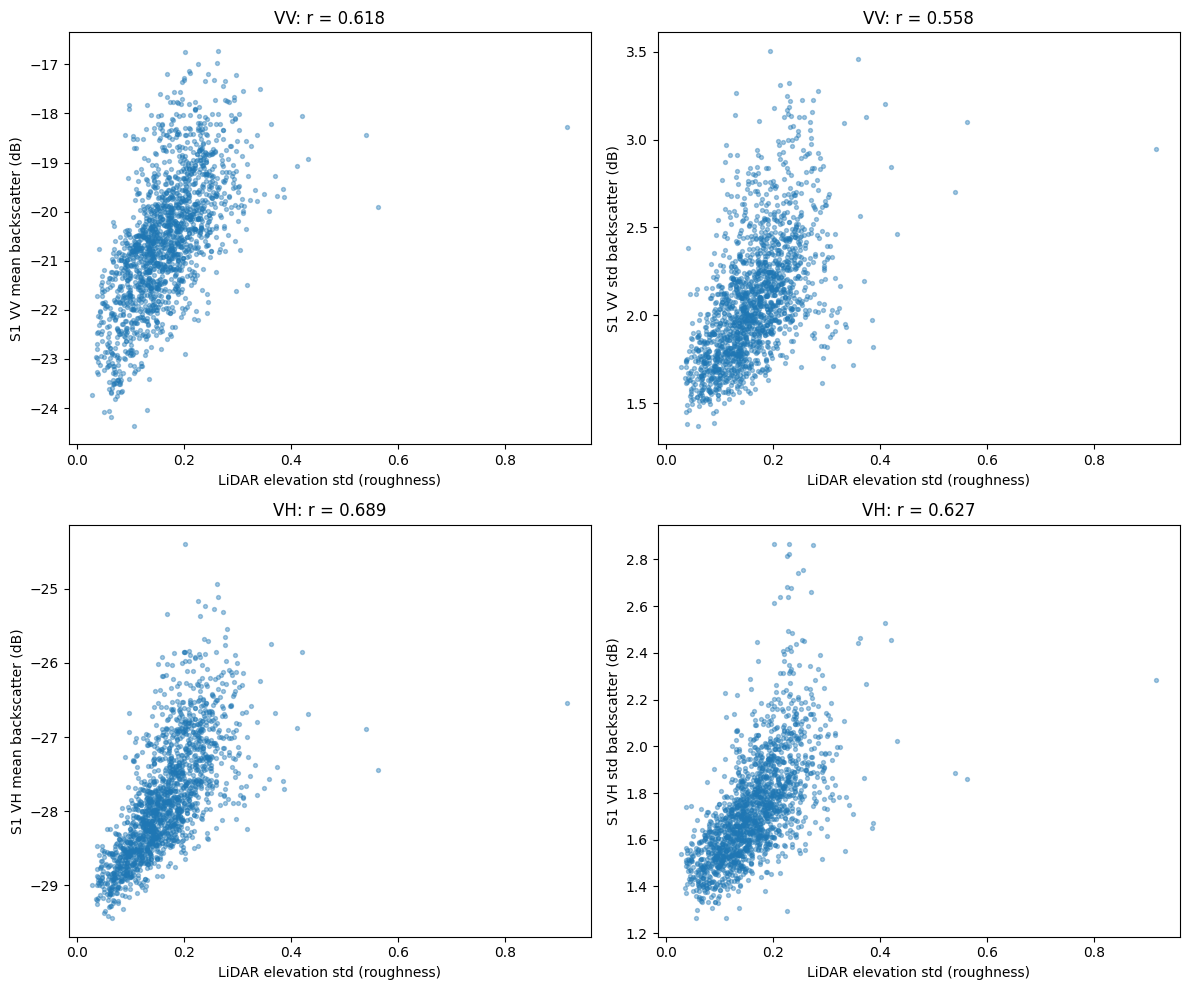

In [9]:
def compute_collocation_quality_stats(lidar_patches_dir, out_s1_dir, timestep=0, pol_labels=("VV", "VH")):
    sample_dirs = sorted(glob_module.glob(os.path.join(out_s1_dir, "s1_patch_*")))
    roughness_vals, pids = [], []
    band_mean_vals = band_std_vals = None
    n_bands = None

    for s1_dir in sample_dirs:
        pid = os.path.basename(s1_dir).split("_")[-1]
        lid_path = os.path.join(lidar_patches_dir, f"lidar_patch_{pid}.tif")
        if not os.path.exists(lid_path):
            continue
        with rasterio.open(lid_path) as src:
            elev = src.read(1)
            mask = src.read(2).astype(bool)
        if mask.sum() < 10:
            continue

        t_path = os.path.join(s1_dir, f"t{timestep}.tif")
        if not os.path.exists(t_path):
            continue
        with rasterio.open(t_path) as src:
            arr = src.read()
        if n_bands is None:
            n_bands = arr.shape[0]
            band_mean_vals = [[] for _ in range(n_bands)]
            band_std_vals = [[] for _ in range(n_bands)]

        with np.errstate(divide="ignore", invalid="ignore"):
            arr_db = 10 * np.log10(np.where(arr > 0, arr, np.nan))
        if np.all(np.isnan(arr_db)):
            continue

        pids.append(pid)
        roughness_vals.append(float(np.std(elev[mask])))
        for b in range(n_bands):
            band_mean_vals[b].append(float(np.nanmean(arr_db[b])))
            band_std_vals[b].append(float(np.nanstd(arr_db[b])))

    roughness_vals = np.array(roughness_vals)
    labels = list(pol_labels[:n_bands]) if n_bands <= len(pol_labels) else [f"band{b+1}" for b in range(n_bands)]
    print(f"Computed stats for {len(pids)} patches")

    fig, axes = plt.subplots(n_bands, 2, figsize=(12, 5 * n_bands), squeeze=False)
    corr_results = {}
    for b in range(n_bands):
        mean_vals = np.array(band_mean_vals[b])
        std_vals = np.array(band_std_vals[b])
        corr_mean = np.corrcoef(roughness_vals, mean_vals)[0, 1]
        corr_std = np.corrcoef(roughness_vals, std_vals)[0, 1]
        corr_results[labels[b]] = (corr_mean, corr_std)
        print(f"[{labels[b]}] Correlation: LiDAR roughness vs mean (dB): {corr_mean:.3f}")
        print(f"[{labels[b]}] Correlation: LiDAR roughness vs std (dB):  {corr_std:.3f}")

        axes[b, 0].scatter(roughness_vals, mean_vals, s=8, alpha=0.4)
        axes[b, 0].set_xlabel("LiDAR elevation std (roughness)")
        axes[b, 0].set_ylabel(f"S1 {labels[b]} mean backscatter (dB)")
        axes[b, 0].set_title(f"{labels[b]}: r = {corr_mean:.3f}")

        axes[b, 1].scatter(roughness_vals, std_vals, s=8, alpha=0.4)
        axes[b, 1].set_xlabel("LiDAR elevation std (roughness)")
        axes[b, 1].set_ylabel(f"S1 {labels[b]} std backscatter (dB)")
        axes[b, 1].set_title(f"{labels[b]}: r = {corr_std:.3f}")

    plt.tight_layout()
    plt.show()

    return pids, roughness_vals, band_mean_vals, band_std_vals, corr_results

_ = compute_collocation_quality_stats(lidar_patches_dir, out_s1_dir)